# Verify URMA Student Action Errors

Compare per-action teacher error for the ANN student and the long-best bootstrap SNN loaded from the sweep output.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

NOTEBOOK_CANDIDATES = [
    Path.cwd(),
    Path("/app/one_policy_to_run_them_all/snn"),
    Path("/app/lava-dl/tutorials/lava/lib/dl/bootstrap/urma"),
]
NOTEBOOK_DIR = next(
    (path for path in NOTEBOOK_CANDIDATES if (path / "teacher_student_dagger_dataset.npz").exists()),
    None,
)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError(
        "Could not find teacher_student_dagger_dataset.npz in: "
        + ", ".join(str(path) for path in NOTEBOOK_CANDIDATES)
    )

LAVA_SRC = Path("/app/lava-dl/src")
for path in (NOTEBOOK_DIR, LAVA_SRC):
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

import lava.lib.dl.bootstrap as bootstrap

from train_student import load_student_model_from_checkpoint, load_teacher_dataset


def resolve_notebook_path(path):
    path = Path(path)
    return path if path.is_absolute() else NOTEBOOK_DIR / path


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LONG_BEST_RESULT_PATH = NOTEBOOK_DIR / "experiments" / "snn_v1_points_1_2" / "20260619T050231Z" / "long_best_result.json"
long_best_result = json.loads(LONG_BEST_RESULT_PATH.read_text())
NETWORK_PATH = Path(long_best_result["checkpoint_path"])
HISTORY_PATH = next(NETWORK_PATH.parent.glob("*_training_history.json"))
long_best_history = json.loads(HISTORY_PATH.read_text())
SNN_CONFIG = long_best_history["config"]

DATASET_PATH = resolve_notebook_path(SNN_CONFIG["paths"]["dataset"])
ANN_CHECKPOINT_PATH = resolve_notebook_path(SNN_CONFIG["paths"]["ann_checkpoint"])
EVAL_SAMPLES = SNN_CONFIG["training"].get("val_eval_samples") or 10_000
EVAL_BATCH_SIZE = SNN_CONFIG["training"].get("val_batch_size") or 1024


print(f"device: {DEVICE}")
print(f"notebook dir: {NOTEBOOK_DIR}")
print(f"dataset: {DATASET_PATH}")
print(f"ann checkpoint: {ANN_CHECKPOINT_PATH}")
print(f"long-best result: {LONG_BEST_RESULT_PATH}")
print(f"long-best history: {HISTORY_PATH}")
print(f"bootstrap network: {NETWORK_PATH}")
print(f"eval samples: {EVAL_SAMPLES}")
print(f"eval batch size: {EVAL_BATCH_SIZE}")


device: cuda
notebook dir: /app/one_policy_to_run_them_all/snn
dataset: /app/one_policy_to_run_them_all/snn/teacher_student_dagger_dataset.npz
ann checkpoint: /app/one_policy_to_run_them_all/snn/student_model_latest.pth
long-best result: /app/one_policy_to_run_them_all/snn/experiments/snn_v1_points_1_2/20260619T050231Z/long_best_result.json
long-best history: /app/one_policy_to_run_them_all/snn/experiments/snn_v1_points_1_2/20260619T050231Z/long_best/long_e300_ts20_iw1_thr0p2_cd0p3_vd0p02/long_e300_ts20_iw1_thr0p2_cd0p3_vd0p02_training_history.json
bootstrap network: /app/one_policy_to_run_them_all/snn/experiments/snn_v1_points_1_2/20260619T050231Z/long_best/long_e300_ts20_iw1_thr0p2_cd0p3_vd0p02/long_e300_ts20_iw1_thr0p2_cd0p3_vd0p02_network.pt
eval samples: 20000
eval batch size: 1024


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Bootstrap SNN Definition

The long-best checkpoint is a raw state_dict, so the verification notebook recreates the same network architecture from the saved training config before loading the weights.

In [2]:
class Network(torch.nn.Module):
    def __init__(
        self,
        input_dim=668,
        output_dim=24,
        hidden_dims=(1024, 1024, 1024, 1024, 1024),
        time_steps=5,
        input_strategy="signed_split",
        input_weight=2.0,
        input_bias=0.0,
        weight_norm=False,
        weight_scale=1.0,
        delay_shift=False,
        neuron=None,
    ):
        super().__init__()
        self.input_dim = int(input_dim)
        self.output_dim = int(output_dim)
        self.hidden_dims = tuple(int(dim) for dim in hidden_dims)
        self.time_steps = int(time_steps)
        self.input_strategy = input_strategy
        if self.input_strategy not in {"identity", "signed_split"}:
            raise ValueError(f"Unsupported input_strategy: {self.input_strategy}")
        self.encoded_input_dim = self.input_dim * 2 if self.input_strategy == "signed_split" else self.input_dim

        neuron_params = dict(
            neuron
            or {
                "threshold": 0.5,
                "current_decay": 0.3,
                "voltage_decay": 0.02,
                "tau_grad": 1.0,
                "scale_grad": 1.0,
            }
        )
        neuron_params_norm = dict(neuron_params)

        blocks = [
            bootstrap.block.cuba.Input(neuron_params, weight=input_weight, bias=input_bias, delay_shift=delay_shift),
            bootstrap.block.cuba.Flatten(),
        ]
        prev_dim = self.encoded_input_dim
        for hidden_dim in self.hidden_dims:
            blocks.append(
                bootstrap.block.cuba.Dense(
                    neuron_params_norm,
                    prev_dim,
                    hidden_dim,
                    weight_norm=weight_norm,
                    weight_scale=weight_scale,
                    delay_shift=delay_shift,
                )
            )
            prev_dim = hidden_dim
        blocks.append(
            bootstrap.block.cuba.Affine(
                neuron_params,
                prev_dim,
                self.output_dim,
                weight_norm=weight_norm,
                weight_scale=weight_scale,
                dynamics=False,
            )
        )
        self.blocks = torch.nn.ModuleList(blocks)

    def encode_input(self, x):
        if x.ndim == 1:
            x = x.reshape(1, -1)
        if x.ndim > 2:
            x = x.reshape(x.shape[0], -1)
        if x.shape[1] != self.input_dim:
            raise ValueError(f"Expected {self.input_dim} student observation features, received {x.shape[1]}.")
        if self.input_strategy == "identity":
            return x
        return torch.cat([torch.relu(x), torch.relu(-x)], dim=1)

    def forward(self, x, mode):
        x = self.encode_input(x)
        x = x.reshape(x.shape[0], self.encoded_input_dim, 1, 1, 1)

        if mode.base_mode != bootstrap.Mode.ANN and self.time_steps > 1:
            x = x.repeat(1, 1, 1, 1, self.time_steps)

        for block, m in zip(self.blocks, mode):
            x = block(x, mode=m)

        while x.ndim > 3 and x.shape[-2] == 1:
            x = x.squeeze(-2)
        if x.ndim == 2:
            x = x.unsqueeze(-1)
        return x


## Load Data And Models

In [3]:
eval_states, eval_teacher_actions = load_teacher_dataset(DATASET_PATH, max_samples=EVAL_SAMPLES)
ann_student, ann_architecture = load_student_model_from_checkpoint(ANN_CHECKPOINT_PATH, device=DEVICE)

bootstrap_snn = Network(**SNN_CONFIG["model"]).to(DEVICE)
bootstrap_snn.load_state_dict(torch.load(NETWORK_PATH, map_location=DEVICE))
bootstrap_snn.eval()

print("eval states:", tuple(eval_states.shape))
print("eval actions:", tuple(eval_teacher_actions.shape))
print("ANN architecture:", ann_architecture)
print("SNN config:", SNN_CONFIG["model"])


eval states: (20000, 668)
eval actions: (20000, 24)
ANN architecture: {'input_dim': 668, 'output_dim': 24, 'hidden_dims': [1024, 1024, 1024, 1024, 1024]}
SNN config: {'input_dim': 668, 'output_dim': 24, 'hidden_dims': [1024, 1024, 1024, 1024, 1024], 'time_steps': 20, 'input_strategy': 'signed_split', 'input_weight': 1.0, 'input_bias': 0.0, 'weight_norm': False, 'weight_scale': 1.0, 'delay_shift': False, 'neuron': {'threshold': 0.2, 'current_decay': 0.3, 'voltage_decay': 0.02, 'tau_grad': 1.0, 'scale_grad': 1.0}}


## Evaluate Action Errors

In [4]:
def percentage_error(predictions, targets):
    numerator = torch.linalg.norm(predictions - targets, dim=1)
    denominator = torch.linalg.norm(targets, dim=1).clamp_min(1e-8)
    return 100.0 * numerator / denominator


def iter_batches(tensor, batch_size):
    for start in range(0, tensor.shape[0], batch_size):
        yield tensor[start : start + batch_size]


scheduler = bootstrap.routine.Scheduler()
snn_mode = scheduler.mode(100, 0, False)
ann_action_batches = []
bootstrap_action_batches = []

with torch.no_grad():
    for state_batch in iter_batches(eval_states, EVAL_BATCH_SIZE):
        state_batch = state_batch.to(DEVICE)
        ann_action_batches.append(ann_student(state_batch).detach().cpu())
        raw_bootstrap_actions = bootstrap_snn(state_batch, mode=snn_mode)
        bootstrap_action_batches.append(
            torch.mean(raw_bootstrap_actions, dim=-1).reshape(state_batch.shape[0], -1).detach().cpu()
        )

ann_actions = torch.cat(ann_action_batches, dim=0)
bootstrap_actions = torch.cat(bootstrap_action_batches, dim=0)

assert ann_actions.shape == eval_teacher_actions.shape, (ann_actions.shape, eval_teacher_actions.shape)
assert bootstrap_actions.shape == eval_teacher_actions.shape, (bootstrap_actions.shape, eval_teacher_actions.shape)

ann_error = percentage_error(ann_actions, eval_teacher_actions)
bootstrap_error = percentage_error(bootstrap_actions, eval_teacher_actions)

print(f"ANN student mean percentage error: {ann_error.mean().item():.4f}%")
print(f"ANN student median percentage error: {ann_error.median().item():.4f}%")
print(f"Bootstrap SNN mean percentage error: {bootstrap_error.mean().item():.4f}%")
print(f"Bootstrap SNN median percentage error: {bootstrap_error.median().item():.4f}%")


ANN student mean percentage error: 2.2037%
ANN student median percentage error: 1.7171%
Bootstrap SNN mean percentage error: 12.1945%
Bootstrap SNN median percentage error: 9.7749%


## Visualize Per-Action Mean Absolute Error

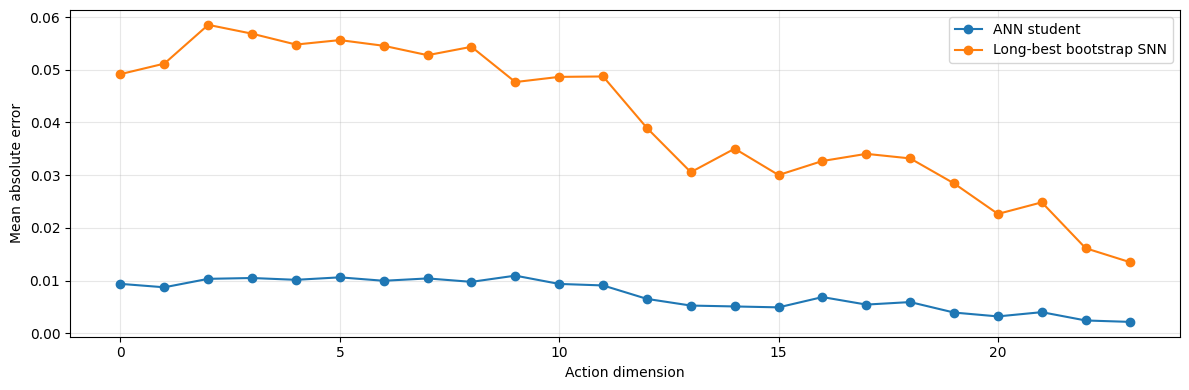

In [5]:
ann_mae_by_dim = (ann_actions - eval_teacher_actions).abs().mean(dim=0).numpy()
bootstrap_mae_by_dim = (bootstrap_actions - eval_teacher_actions).abs().mean(dim=0).numpy()

action_index = np.arange(eval_teacher_actions.shape[1])
plt.figure(figsize=(12, 4))
plt.plot(action_index, ann_mae_by_dim, marker="o", label="ANN student")
plt.plot(action_index, bootstrap_mae_by_dim, marker="o", label="Long-best bootstrap SNN")
plt.xlabel("Action dimension")
plt.ylabel("Mean absolute error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()